In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from simulator import *

In [29]:
def compute_summary_sim(infected_sim, rewiring_sim, final_degree_sim):
    # --- Infection ---
    peak_I = np.max(infected_sim)
    time_peak = np.argmax(infected_sim)
    final_I = infected_sim[-1]

    # --- Rewiring ---
    total_rewires = np.sum(rewiring_sim)
    mean_rewires = np.mean(rewiring_sim)

    # --- Degree distribution ---
    degrees = np.arange(len(final_degree_sim))
    prob = final_degree_sim / (np.sum(final_degree_sim) + 1e-8)

    mean_degree = np.sum(degrees * prob)
    var_degree = np.sum((degrees - mean_degree) ** 2 * prob)

    return np.array([
        peak_I,
        time_peak,
        final_I,
        total_rewires,
        mean_rewires,
        mean_degree,
        var_degree
    ])

In [28]:
def compute_summary_summary(infected, rewiring, final_degree):
    # --- Infection ---
    mean_inf = infected.groupby("time")["infected_fraction"].mean().values
    peak_I = np.max(mean_inf)
    time_peak = np.argmax(mean_inf)
    final_I = mean_inf[-1]

    # Rewiring
    mean_rew = rewiring.groupby("time")["rewire_count"].mean().values
    total_rewires = np.sum(mean_rew)
    mean_rewires = np.mean(mean_rew)

    # Degree
    final_degree["prob"] = final_degree.groupby("replicate_id")["count"].transform(lambda x: x / x.sum())
    deg_avg = final_degree.groupby("degree")["prob"].mean().values
    degrees = np.arange(len(deg_avg))
    mean_degree = np.sum(degrees * deg_avg)
    var_degree = np.sum((degrees - mean_degree)**2 * deg_avg)

    return np.array([
        peak_I,
        time_peak,
        final_I,
        total_rewires,
        mean_rewires,
        mean_degree,
        var_degree
    ])

In [17]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewiring_obs = pd.read_csv("data/rewiring_timeseries.csv")
final_degree_obs = pd.read_csv("data/final_degree_histograms.csv")

S_obs = compute_summary(infected_obs, rewiring_obs, final_degree_obs)

In [18]:
def sample_prior():
    beta = np.random.uniform(0.05, 0.50)
    gamma = np.random.uniform(0.02, 0.20)
    rho = np.random.uniform(0.0, 0.8)
    return beta, gamma, rho

In [19]:
N = 5000  # number of simulations

params = []
summaries = []
distances = []

for i in range(N):
    beta, gamma, rho = sample_prior()
    
    inf_sim, rew_sim, deg_sim = simulate(beta, gamma, rho)
    S_sim = compute_summary_sim(inf_sim, rew_sim, deg_sim)
    
    params.append([beta, gamma, rho])
    summaries.append(S_sim)

params = np.array(params)
summaries = np.array(summaries)

In [21]:
# Normalize using observed scale
mean_obs = S_obs
std_obs = summaries.std(axis=0) + 1e-8

S_obs_norm = (S_obs - mean_obs) / std_obs
summaries_norm = (summaries - mean_obs) / std_obs

distances = np.linalg.norm(summaries_norm - S_obs_norm, axis=1)

In [22]:
# Keep top 2%
epsilon = np.quantile(distances, 0.02)

accepted = params[distances <= epsilon]

print("Accepted samples:", len(accepted))

Accepted samples: 100


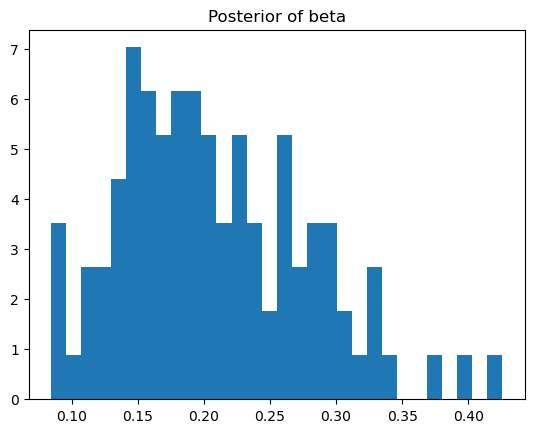

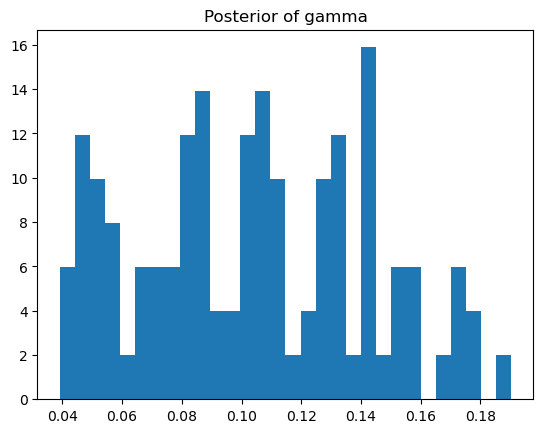

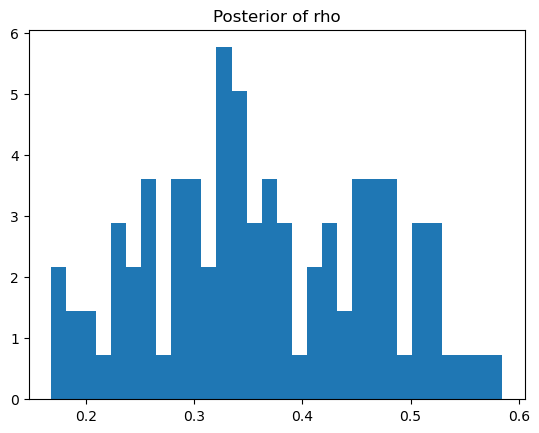

In [23]:
labels = ["beta", "gamma", "rho"]

for i in range(3):
    plt.hist(accepted[:, i], bins=30, density=True)
    plt.title(f"Posterior of {labels[i]}")
    plt.show()

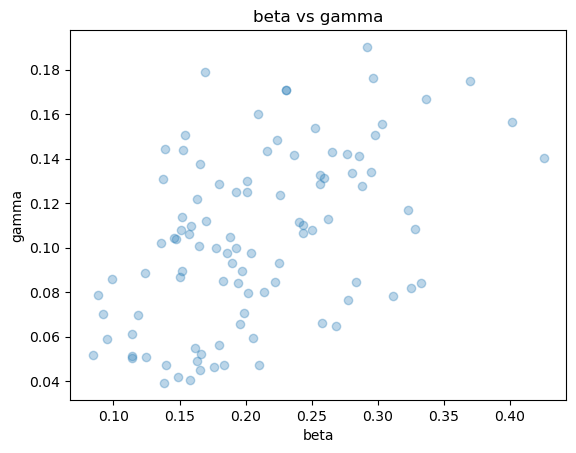

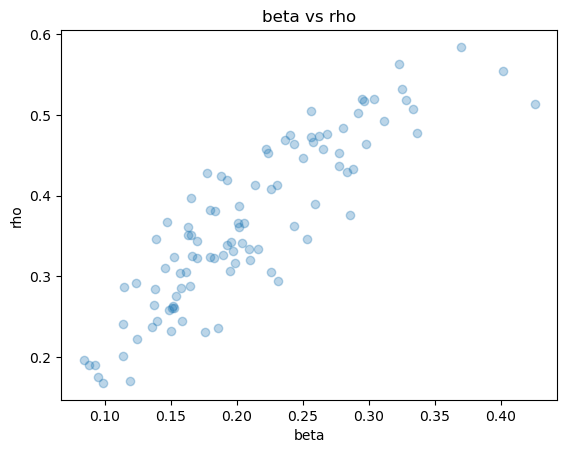

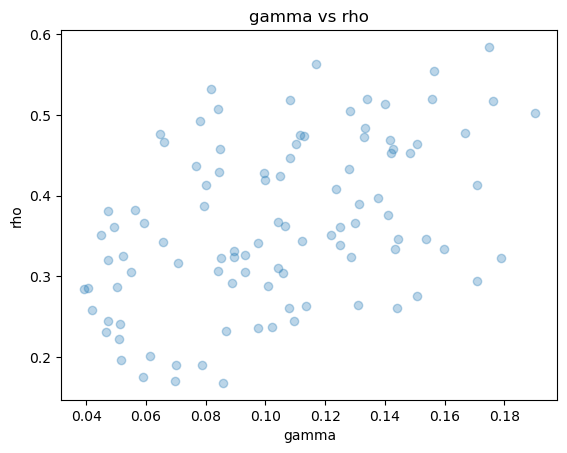

In [24]:
for i, j in itertools.combinations(range(3), 2):
    plt.scatter(accepted[:, i], accepted[:, j], alpha=0.3)
    plt.xlabel(labels[i])
    plt.ylabel(labels[j])
    plt.title(f"{labels[i]} vs {labels[j]}")
    plt.show()

In [35]:
def simulate_average(beta, gamma, rho, M=40):
    sims_inf = []
    sims_rew = []

    for _ in range(M):
        obj1, obj2, obj3 = simulate(beta, gamma, rho)
        sims_inf.append(obj1)
        sims_rew.append(obj2)

    mean_inf = np.mean(sims_inf, axis=0)
    mean_rew = np.mean(sims_rew, axis=0)

    return mean_inf, mean_rew

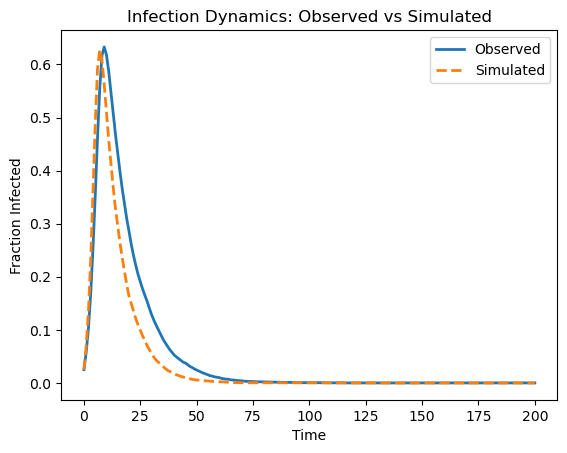

In [36]:
mean_inf_obs = infected_obs.groupby("time")["infected_fraction"].mean().values
mean_rew_obs = rewiring_obs.groupby("time")["rewire_count"].mean().values

beta_hat = np.mean(accepted[:, 0])
gamma_hat = np.mean(accepted[:, 1])
rho_hat = np.mean(accepted[:, 2])

time = np.arange(len(mean_inf_obs))

mean_inf_sim, mean_rew_sim = simulate_average(beta_hat, gamma_hat, rho_hat)

plt.figure()
plt.plot(time, mean_inf_obs, label="Observed", linewidth=2)
plt.plot(time, mean_inf_sim, linestyle="--", label="Simulated", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Fraction Infected")
plt.title("Infection Dynamics: Observed vs Simulated")
plt.legend()
plt.show()

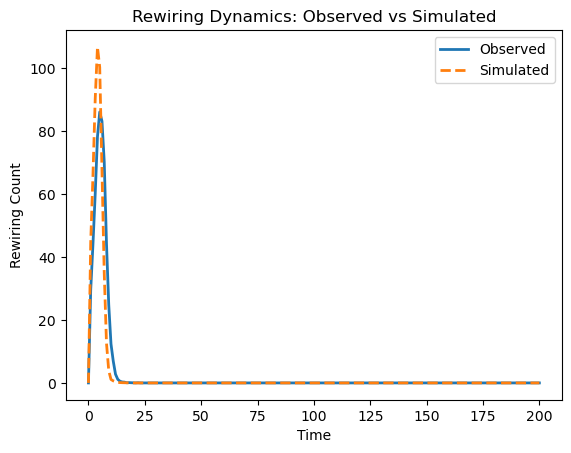

In [37]:
time = np.arange(len(mean_rew_obs))

plt.figure()
plt.plot(time, mean_rew_obs, label="Observed", linewidth=2)
plt.plot(time, mean_rew_sim, linestyle="--", label="Simulated", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Rewiring Count")
plt.title("Rewiring Dynamics: Observed vs Simulated")
plt.legend()
plt.show()

In [25]:
# Part 3

def compute_summary_sim(infected_sim, rewiring_sim, final_degree_sim, mode="full"):
    # Infection
    peak_I = np.max(infected_sim)
    time_peak = np.argmax(infected_sim)
    final_I = infected_sim[-1]

    summaries = [peak_I, time_peak, final_I]

    if mode in ["rewiring", "full"]:
        total_rewires = np.sum(obj2)
        mean_rewires = np.mean(obj2)
        summaries += [total_rewires, mean_rewires]

    if mode == "full":
        degrees = np.arange(len(obj3))
        prob = obj3 / (np.sum(obj3) + 1e-8)
        mean_degree = np.sum(degrees * prob)
        var_degree = np.sum((degrees - mean_degree)**2 * prob)
        summaries += [mean_degree, var_degree]

    return np.array(summaries)

In [27]:
modes = ["infection", "rewiring", "full"]
results = {}

for mode in modes:
    summaries = []
    params = []

    for i in range(N):
        beta, gamma, rho = sample_prior()
        
        inf_sim, rew_sim, deg_sim = simulate(beta, gamma, rho)
        S_sim = compute_summary_sim(inf_sim, rew_sim, deg_sim, mode=mode)

        summaries.append(S_sim)
        params.append([beta, gamma, rho])

    summaries = np.array(summaries)
    params = np.array(params)

    # Normalize
    S_obs_mode = compute_summary_sim(infected_obs, rewiring_obs, final_degree_obs, mode=mode)

    std = summaries.std(axis=0) + 1e-8
    dist = np.linalg.norm((summaries - S_obs_mode)/std, axis=1)

    epsilon = np.quantile(dist, 0.02)
    accepted = params[dist <= epsilon]

    results[mode] = accepted

KeyError: -1